# Analysis of bike degradation in the simulatior

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

In [115]:
# Load file
hourly_df = pd.read_csv(
    r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\sjovik_sund_TD_W34_old_V1_D17520h_T5_03031509_seed1_alpha0.000_results_hourly_seed_1.csv"
)

failure_df = pd.read_csv(
    r"C:\Users\Minamsj\FOMOsim\policies\sjovik_sund\simulation_results\sjovik_sund_TD_W34_old_V1_D17520h_T5_03031509_seed1_alpha0.000_results_component_failures_seed_1.csv" )

# Keep only days up to 90
hourly_df = hourly_df[hourly_df['Day'] <= 60]

# Aggregate total component failures per day
daily_failures = (
    hourly_df.groupby('Day')['Total Component Failures']
    .sum()
    .reset_index()
)

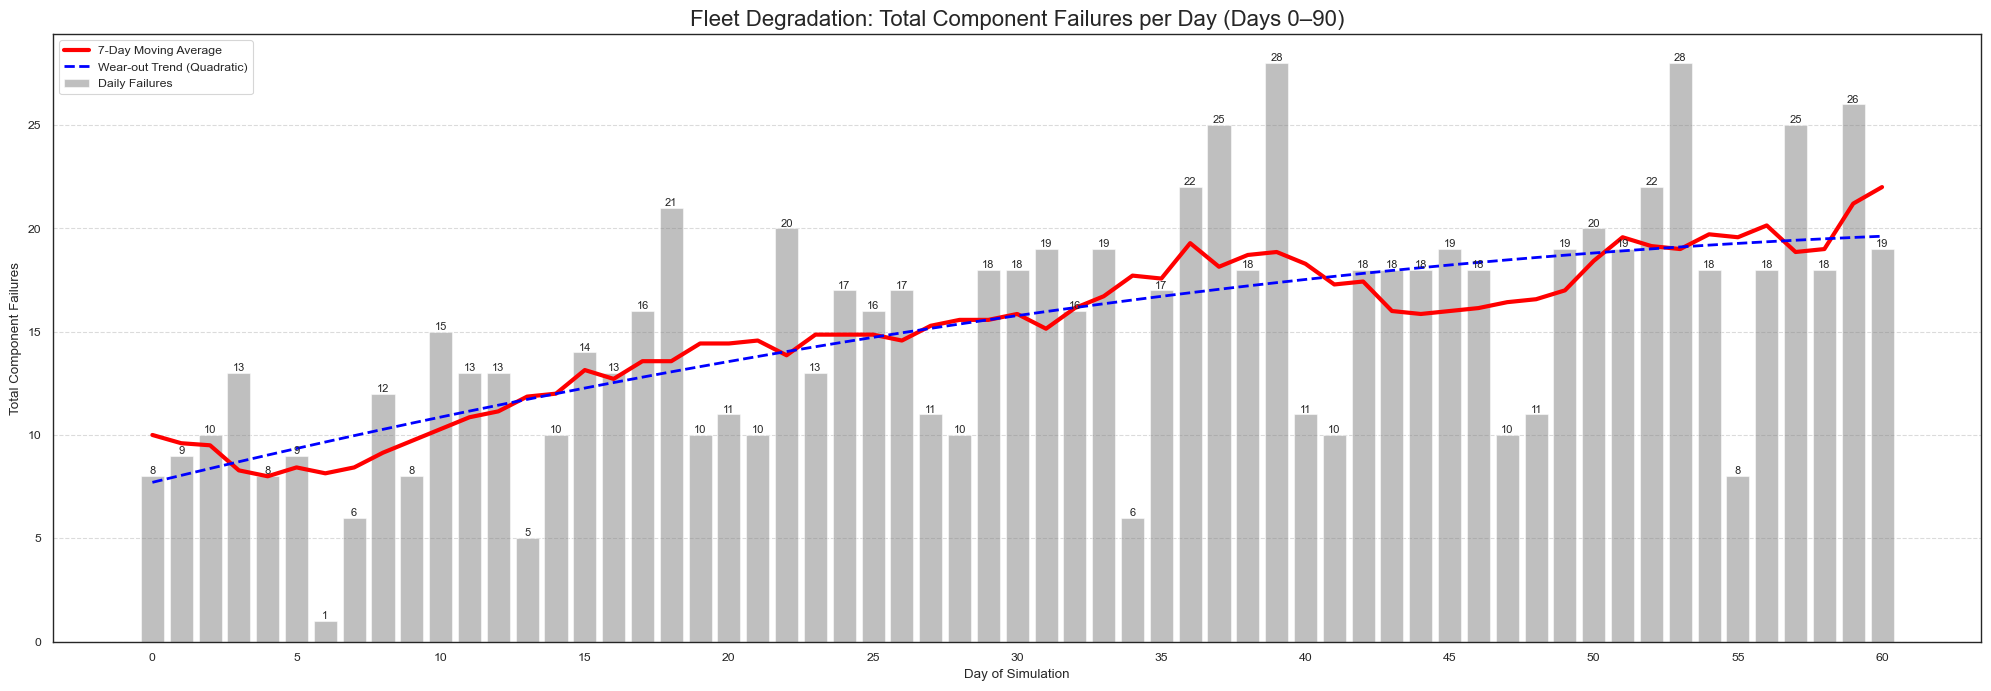

In [116]:
import numpy as np

# 1. Calculate a 7-day rolling average (Symmetric)
# We use min_periods=1 to ensure we have data for the start of the simulation
daily_failures['Rolling_Avg'] = daily_failures['Total Component Failures'].rolling(window=7, center=True, min_periods=1).mean()

# 2. Calculate a Quadratic Polynomial Trendline
# Since k > 1 for all components, failures should theoretically accelerate
z = np.polyfit(daily_failures['Day'], daily_failures['Total Component Failures'], 2)
p = np.poly1d(z)
daily_failures['Poly_Trend'] = p(daily_failures['Day'])

# Plot
plt.figure(figsize=(20, 7))
bars = plt.bar(daily_failures['Day'], daily_failures['Total Component Failures'], alpha=0.5, label='Daily Failures', color='gray')

# Plotting the moving average
plt.plot(daily_failures['Day'], daily_failures['Rolling_Avg'], color='red', linewidth=3, label='7-Day Moving Average')

# Plotting the polynomial trend
plt.plot(daily_failures['Day'], daily_failures['Poly_Trend'], color='blue', linestyle='--', linewidth=2, label='Wear-out Trend (Quadratic)')

plt.title('Fleet Degradation: Total Component Failures per Day (Days 0–90)', fontsize=16)
plt.xlabel('Day of Simulation')
plt.ylabel('Total Component Failures')
plt.xticks(daily_failures['Day'][::5])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
#plt.savefig('daily_failures_with_trend.png')

C:\Users\Minamsj\AppData\Local\Temp\ipykernel_10768\3636186707.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_unified = df_temp.set_index('Day').groupby(level=0, axis=1).sum()


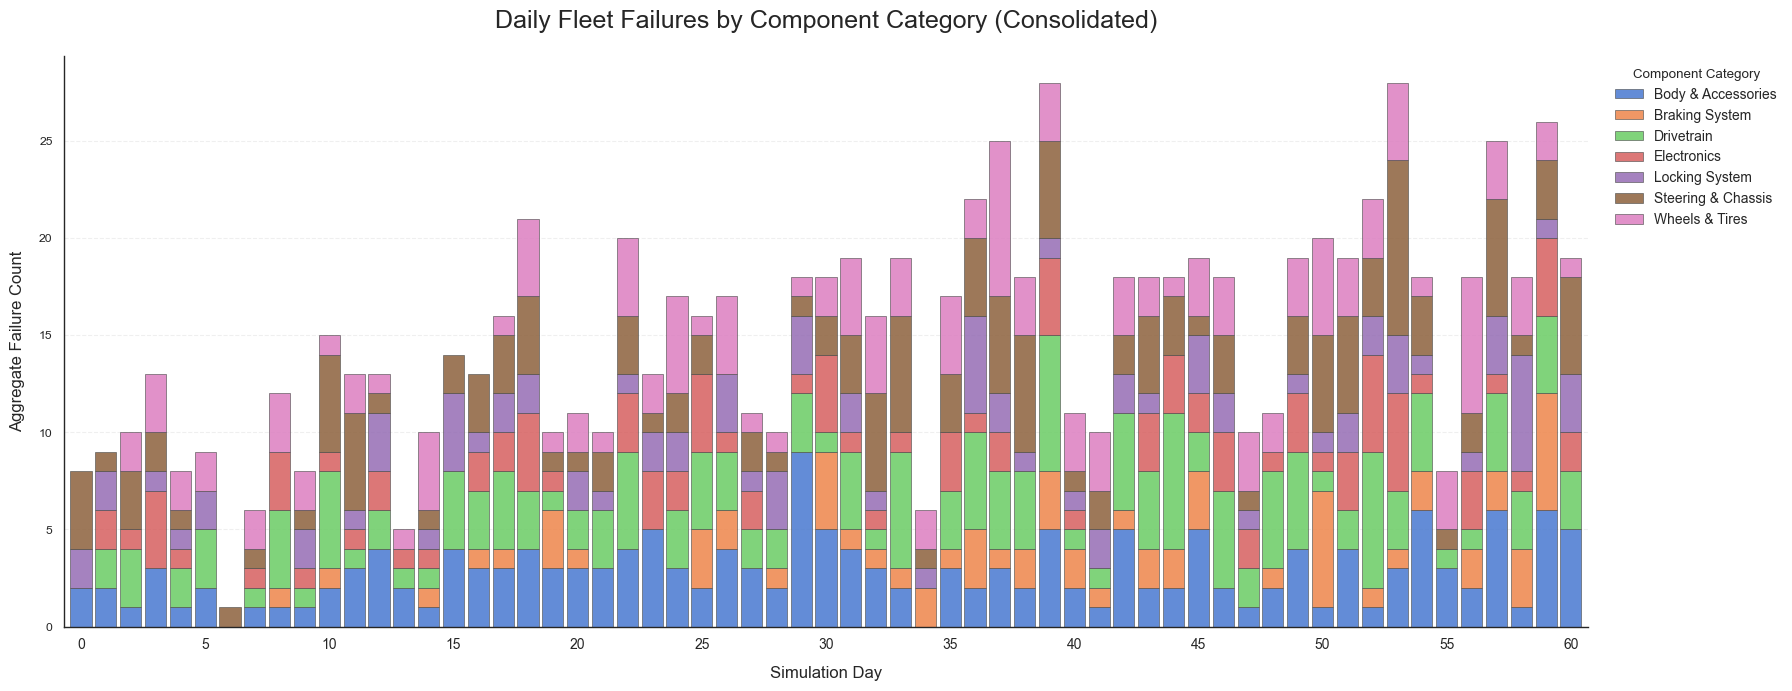

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use a professional seaborn style
sns.set_theme(style="white", context="paper")

# 1. Filter and Prepare Data (Day 0-90)
df_range = hourly_df[hourly_df['Day'] <= 90].copy()
failure_cols = [c for c in df_range.columns if c.startswith('Failures:')]

# 2. Category Cleaning Mapping
clean_map = {c: c.replace('Failures: ', '').split(' (')[0] for c in failure_cols}
df_temp = df_range[['Day'] + failure_cols].rename(columns=clean_map)

# 3. Horizontal Consolidation (Axis 1) followed by Temporal Aggregation (Grouping by Day)
# level=0 refers to the column labels which now have duplicates like 'Drivetrain'
df_unified = df_temp.set_index('Day').groupby(level=0, axis=1).sum()
daily_df = df_unified.groupby('Day').sum()

# 4. Plotting with "Easy on the Eyes" Palette
fig, ax = plt.subplots(figsize=(18, 7))

# 'viridis' is perceptually uniform; 'muted' or 'Set3' are softer alternatives.
# I suggest a custom list of professional colors for 7 categories:
professional_colors = sns.color_palette("muted", n_colors=len(daily_df.columns))

daily_df.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=professional_colors, 
    width=0.85,
    edgecolor='0.3', # Muted gray edge instead of harsh black
    linewidth=0.5,
    alpha=0.85       # Slight transparency softens the impact
)

# 5. Thesis-Level Styling
plt.title('Daily Fleet Failures by Component Category (Consolidated)', fontsize=18, pad=20)
plt.xlabel('Simulation Day', fontsize=12, labelpad=10)
plt.ylabel('Aggregate Failure Count', fontsize=12, labelpad=10)

# Clean X-axis ticks
tick_freq = 5
plt.xticks(
    np.arange(0, len(daily_df), tick_freq), 
    daily_df.index[::tick_freq], 
    rotation=0, 
    fontsize=10
)

# Legend and Grid
plt.legend(
    title='Component Category', 
    bbox_to_anchor=(1.01, 1), 
    loc='upper left', 
    frameon=False, 
    fontsize=10
)

# Remove top and right spines for a modern look
sns.despine()

# Horizontal grid only to reduce clutter
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Minamsj\AppData\Local\Temp\ipykernel_10768\842572546.py:23: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_fix_types = df_fix_types.groupby(map_to_fix_type, axis=1).sum()


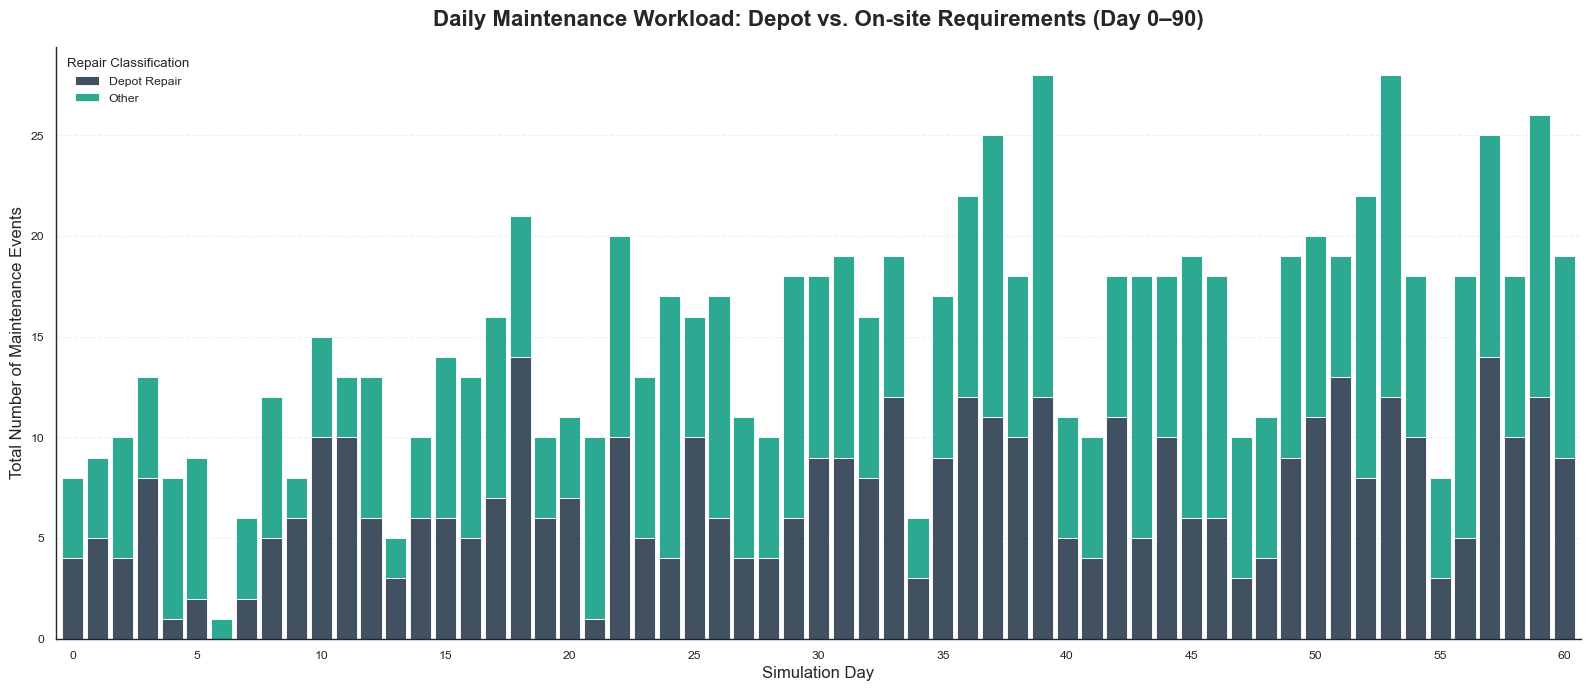

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Professional academic styling
sns.set_theme(style="white", context="paper")

# 1. Filter and Prepare Data (Day 0-90)
df_range = hourly_df[hourly_df['Day'] <= 90].copy()
failure_cols = [c for c in df_range.columns if c.startswith('Failures:')]

# 2. Logic to map columns to the fix type only
def map_to_fix_type(col_name):
    if 'Depot' in col_name:
        return 'Depot Repair'
    elif 'On-site' in col_name:
        return 'On-site Fix'
    return 'Other' # Fallback for unexpected naming

# 3. Aggregate horizontally by Fix Type, then vertically by Day
df_fix_types = df_range[['Day'] + failure_cols].set_index('Day')
df_fix_types = df_fix_types.groupby(map_to_fix_type, axis=1).sum()

# Daily summation
daily_fix_df = df_fix_types.groupby('Day').sum()

# 4. Plotting
fig, ax = plt.subplots(figsize=(16, 7))

# High-contrast but professional colors for the two categories
# Deep blue for Depot (High cost), Soft teal for On-site (Low cost)
fix_colors = ["#2c3e50", "#16a085"] 

daily_fix_df.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=fix_colors, 
    width=0.85,
    edgecolor='white',
    linewidth=0.7,
    alpha=0.9
)

# 5. Thesis-Level Styling
plt.title('Daily Maintenance Workload: Depot vs. On-site Requirements (Day 0–90)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Simulation Day', fontsize=12)
plt.ylabel('Total Number of Maintenance Events', fontsize=12)

# X-axis cleanup
tick_freq = 5
plt.xticks(np.arange(0, len(daily_fix_df), tick_freq), daily_fix_df.index[::tick_freq], rotation=0)

plt.legend(title='Repair Classification', frameon=False, loc='upper left')
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Accumulated damages

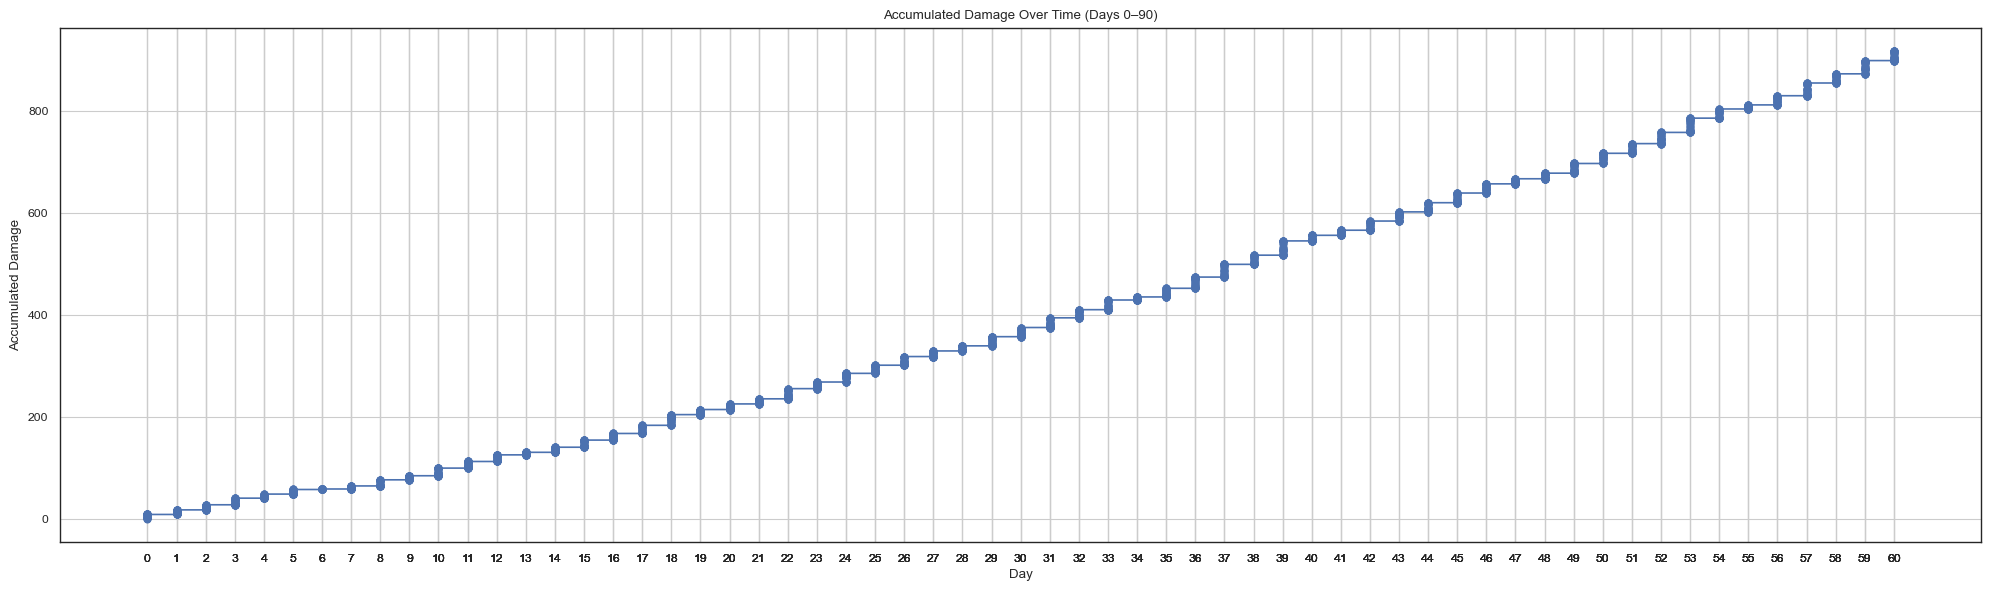

In [119]:
# Show accumulated damage over time, but needs to sum up total_component failures over time
hourly_df['Accumulated Damage'] = hourly_df['Total Component Failures'].cumsum()
plt.figure(figsize=(20, 6))
plt.plot(hourly_df['Day'], hourly_df['Accumulated Damage'], marker='o')
plt.title('Accumulated Damage Over Time (Days 0–90)')
plt.xlabel('Day')
plt.ylabel('Accumulated Damage')
plt.xticks(hourly_df['Day'][::5])
plt.grid()
plt.tight_layout()
plt.show()

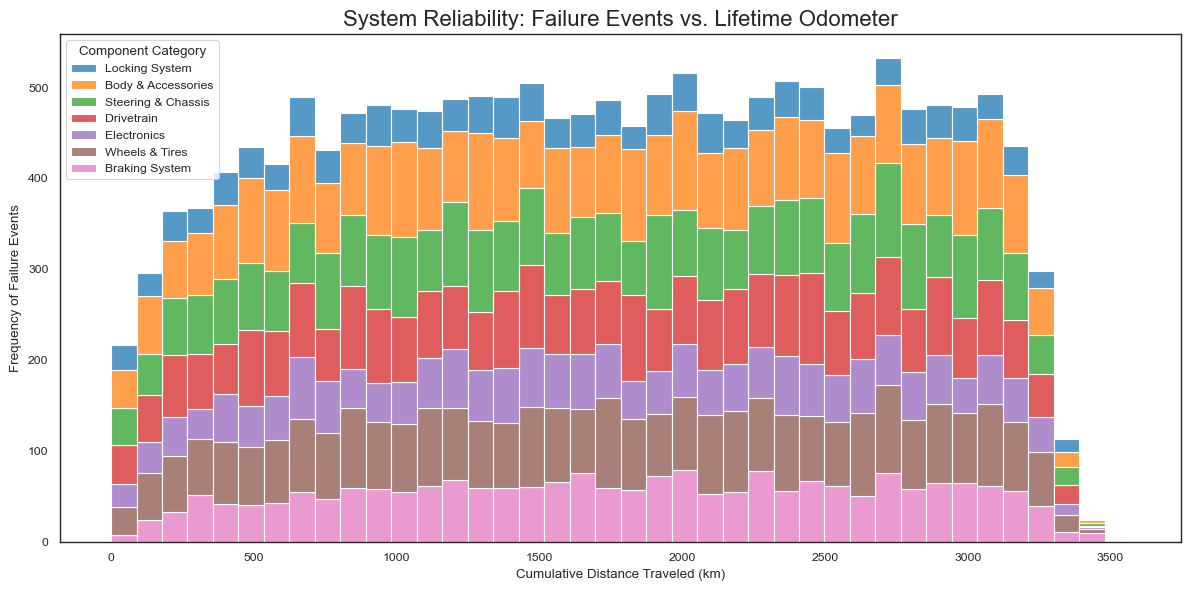

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the figure size is sufficient for the legend
plt.figure(figsize=(12, 6))

# The x-axis maps to 'Odometer (km)' and the hue to 'Component Category'
sns.histplot(
    data=failure_df, 
    x="Total Bike Odometer (km)", 
    hue="Component Category", 
    multiple="stack", 
    bins=40,
    palette="tab10"
)

plt.title('System Reliability: Failure Events vs. Lifetime Odometer', fontsize=16)
plt.xlabel('Cumulative Distance Traveled (km)')
plt.ylabel('Frequency of Failure Events')

# Improving layout to prevent legend overlap
plt.tight_layout()
#plt.savefig('failure_odometer_distribution.png')

C:\Users\Minamsj\AppData\Local\Temp\ipykernel_10768\1296735679.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Component Category', x='Component Odometer (km)',


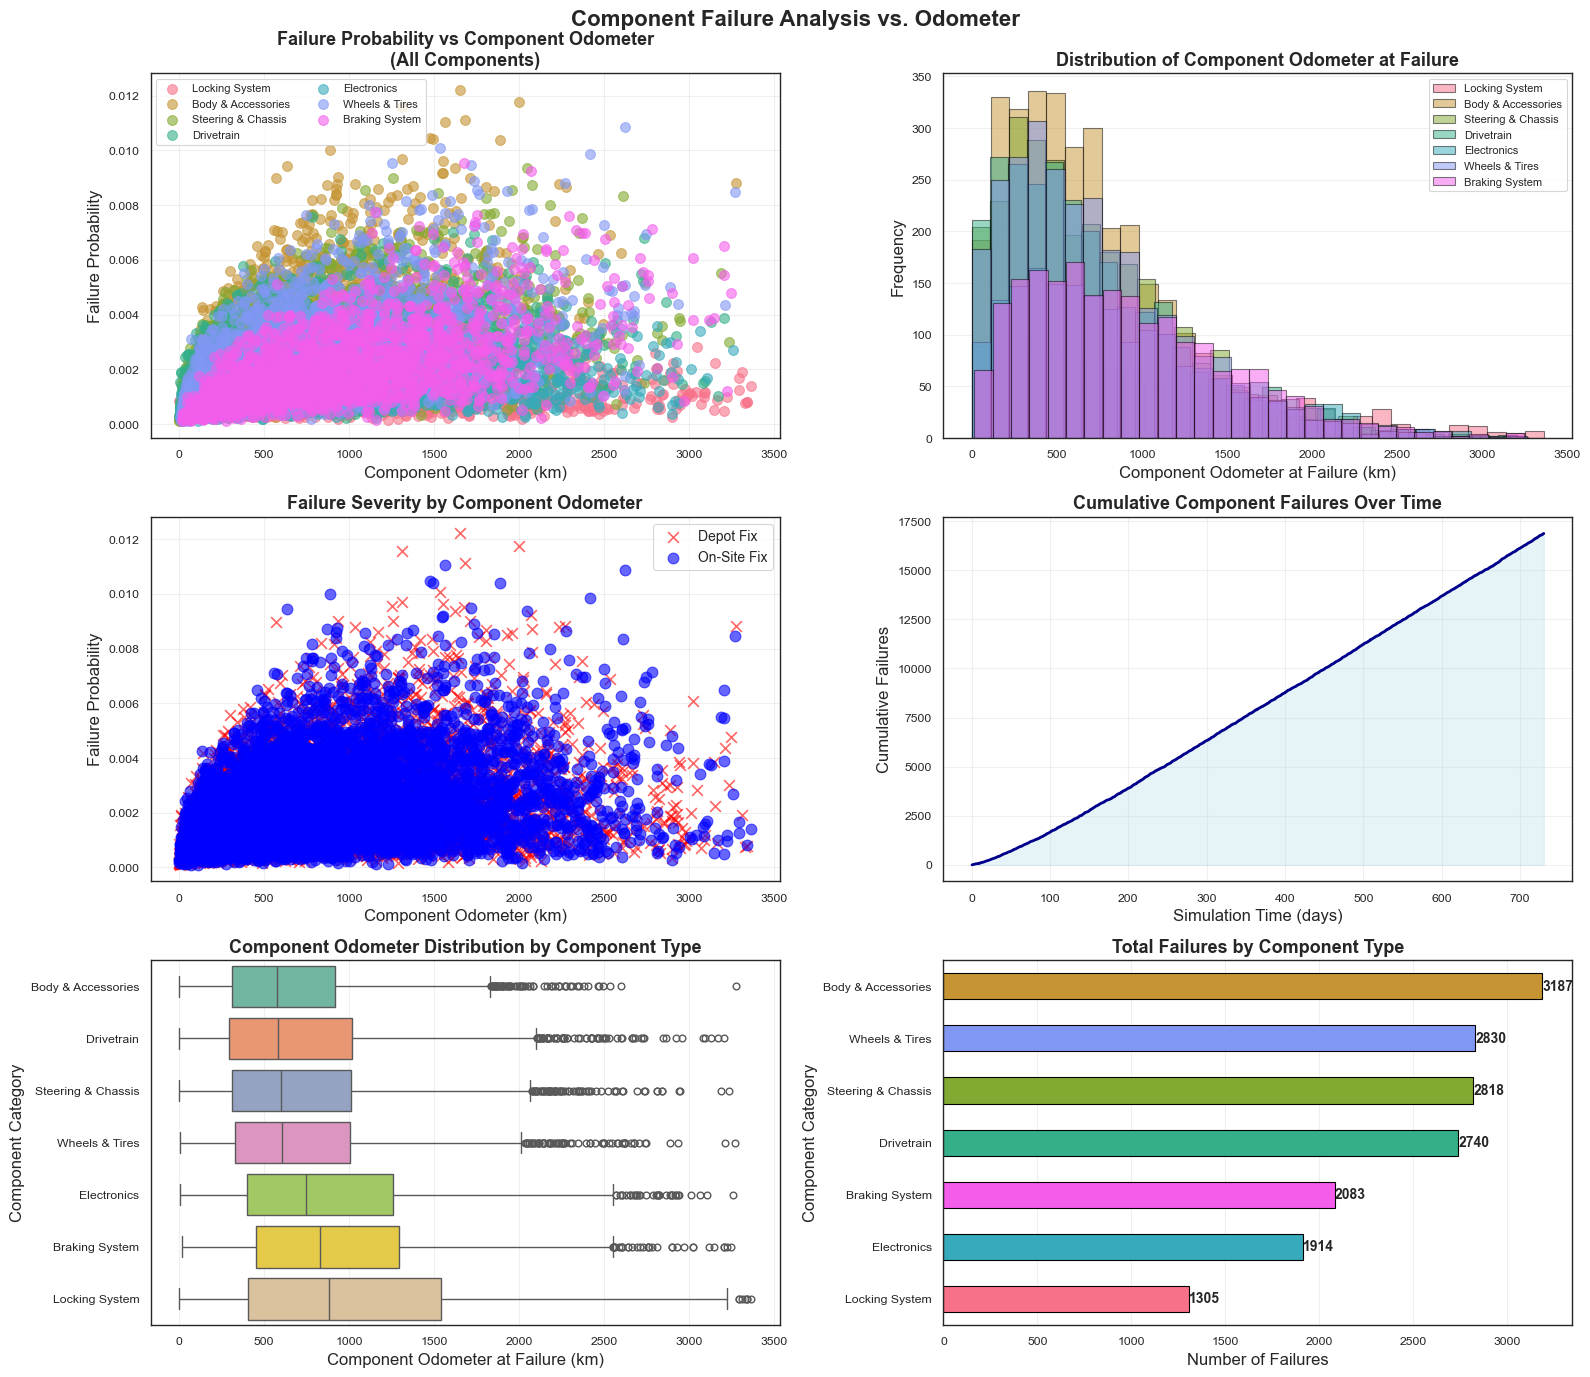

In [121]:
df = failure_df.copy()

# Create figure with multiple subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Component Failure Analysis vs. Odometer', fontsize=16, fontweight='bold')
# ========== PLOT 1: Failures by Component Odometer (All Components) ==========
ax1 = axes[0, 0]
components = df['Component Category'].unique()
colors = sns.color_palette("husl", len(components))

for component, color in zip(components, colors):
    component_df = df[df['Component Category'] == component]
    ax1.scatter(component_df['Component Odometer (km)'], 
                component_df['Failure Probability'], 
                label=component, alpha=0.6, s=50, color=color)

ax1.set_xlabel('Component Odometer (km)', fontsize=12)
ax1.set_ylabel('Failure Probability', fontsize=12)
ax1.set_title('Failure Probability vs Component Odometer\n(All Components)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# ========== PLOT 2: Histogram of Component Odometer at Failure ==========
ax2 = axes[0, 1]
for component, color in zip(components, colors):
    component_df = df[df['Component Category'] == component]
    ax2.hist(component_df['Component Odometer (km)'], 
             bins=30, alpha=0.5, label=component, color=color, edgecolor='black')

ax2.set_xlabel('Component Odometer at Failure (km)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Component Odometer at Failure', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

# ========== PLOT 3: Depot vs On-Site by Component Odometer ==========
ax3 = axes[1, 0]
depot_df = df[df['Needs Depot Fix'] == True]
onsite_df = df[df['Needs On-Site Fix'] == True]

ax3.scatter(depot_df['Component Odometer (km)'], 
            depot_df['Failure Probability'],
            label='Depot Fix', alpha=0.6, s=60, color='red', marker='x')
ax3.scatter(onsite_df['Component Odometer (km)'], 
            onsite_df['Failure Probability'],
            label='On-Site Fix', alpha=0.6, s=60, color='blue', marker='o')

ax3.set_xlabel('Component Odometer (km)', fontsize=12)
ax3.set_ylabel('Failure Probability', fontsize=12)
ax3.set_title('Failure Severity by Component Odometer', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ========== PLOT 4: Cumulative Failures Over Time ==========
ax4 = axes[1, 1]
df_sorted = df.sort_values('Time (minutes)')
df_sorted['Cumulative Failures'] = range(1, len(df_sorted) + 1)

ax4.plot(df_sorted['Time (minutes)'] / (60 * 24), 
         df_sorted['Cumulative Failures'], 
         linewidth=2, color='darkblue')
ax4.fill_between(df_sorted['Time (minutes)'] / (60 * 24), 
                  df_sorted['Cumulative Failures'], 
                  alpha=0.3, color='lightblue')

ax4.set_xlabel('Simulation Time (days)', fontsize=12)
ax4.set_ylabel('Cumulative Failures', fontsize=12)
ax4.set_title('Cumulative Component Failures Over Time', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# ========== PLOT 5: Box Plot - Component Odometer by Component Type ==========
ax5 = axes[2, 0]
component_order = df.groupby('Component Category')['Component Odometer (km)'].median().sort_values().index
sns.boxplot(data=df, y='Component Category', x='Component Odometer (km)', 
            order=component_order, palette='Set2', ax=ax5)

ax5.set_xlabel('Component Odometer at Failure (km)', fontsize=12)
ax5.set_ylabel('Component Category', fontsize=12)
ax5.set_title('Component Odometer Distribution by Component Type', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')

# ========== PLOT 6: Failure Count by Component ==========
ax6 = axes[2, 1]
failure_counts = df['Component Category'].value_counts().sort_values()
colors_bar = [colors[list(components).index(comp)] for comp in failure_counts.index]

failure_counts.plot(kind='barh', ax=ax6, color=colors_bar, edgecolor='black')
ax6.set_xlabel('Number of Failures', fontsize=12)
ax6.set_ylabel('Component Category', fontsize=12)
ax6.set_title('Total Failures by Component Type', fontsize=13, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, v in enumerate(failure_counts.values):
    ax6.text(v + 1, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save figure
#output_path = RESULTS_DIR / 'component_failure_analysis.png'
#plt.savefig(output_path, dpi=300, bbox_inches='tight')
#print(f"\nPlot saved to: {output_path}")

plt.show()